In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
import healpy as hp

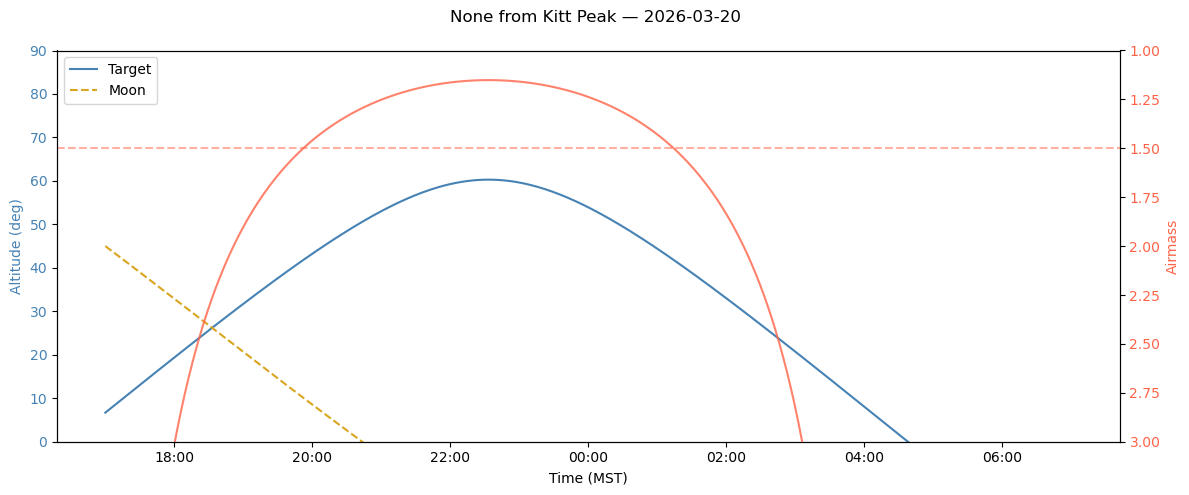

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import astropy.units as u
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_body
from astropy.time import Time
from astroplan import Observer, FixedTarget, AltitudeConstraint, AtNightConstraint
import pytz
from datetime import datetime

site = EarthLocation(lat=31.9634*u.deg, lon=-111.5992*u.deg, height=2096*u.m)
observer = Observer(location=site, name="Kitt Peak", timezone="US/Arizona")

target_coord = SkyCoord(ra=150.1*u.deg, dec=2.382*u.deg, frame='icrs')
target = FixedTarget(coord=target_coord)

constraints = [
    AltitudeConstraint(min=30*u.deg),
    AtNightConstraint.twilight_astronomical(),
]

tz = pytz.timezone("US/Arizona")
start_date = '2026-03-20'

midnight_local = tz.localize(datetime.strptime(f'{start_date} 23:59:59', '%Y-%m-%d %H:%M:%S'))
midnight_utc = Time(midnight_local.astimezone(pytz.utc))

times = midnight_utc + np.linspace(-7, 7, 500) * u.hour
altaz_frame = AltAz(obstime=times, location=site)

target_altaz = target_coord.transform_to(altaz_frame)
alt = target_altaz.alt.deg
airmass = np.where(alt > 0, target_altaz.secz, np.nan)

moon_altaz = get_body('moon', times).transform_to(altaz_frame)
moon_alt = moon_altaz.alt.deg

local_times = [t.to_datetime(timezone=tz) for t in times]

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(local_times, alt, color='steelblue', label='Target')
ax1.plot(local_times, moon_alt, color='goldenrod', ls='--', label='Moon')
ax1.set_xlabel('Time (MST)')
ax1.set_ylabel('Altitude (deg)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_ylim(0, 90)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=tz))
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(local_times, airmass, color='tomato', alpha=0.8)
ax2.axhline(1.5, color='tomato', ls='--', alpha=0.5, label='X = 1.5')
ax2.set_ylabel('Airmass', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
ax2.set_ylim(1, 3)
ax2.invert_yaxis()

fig.suptitle(f'{target.name} from {observer.name} — {start_date}')
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

In [2]:
import astropy.units as u
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_moon, get_sun
from astropy.time import Time
from astroplan import Observer, FixedTarget
import numpy as np
from datetime import datetime, timedelta

# Define your observing site
site = EarthLocation(lat=31.9634*u.deg, lon=-111.5992*u.deg, height=2096*u.m)
observer = Observer(location=site, name="Kitt Peak", timezone="US/Arizona")

# Define your target
target_ra, target_dec = 150.1, 2.382
target_coord = SkyCoord(ra=target_ra*u.deg, dec=target_dec*u.deg, frame='icrs')
target = FixedTarget(coord=target_coord, name="M1")

# Year to analyze
start_date = Time('2026-03-01 00:00:00')
end_date = Time('2026-05-01 00:00:00')

# Iterate through each night
good_nights = []
current_date = start_date

while current_date < end_date:
    # Get sunset and sunrise for the night
    sunset = observer.sun_set_time(current_date, which='next')
    sunrise = observer.sun_rise_time(sunset, which='next')
    
    # Sample the night at 5-minute intervals
    night_times = sunset + np.linspace(0, (sunrise - sunset).to(u.hour).value, 
                                        int((sunrise - sunset).to(u.hour).value * 12)) * u.hour
    
    # Calculate sun altitude to apply 15° twilight constraint
    altaz_frame = AltAz(obstime=night_times, location=site)
    sun_coords = get_sun(night_times)
    sun_altaz = sun_coords.transform_to(altaz_frame)
    
    # Calculate target airmass throughout the night
    target_altaz = target_coord.transform_to(altaz_frame)
    airmass = target_altaz.secz
    
    # Calculate moon altitude throughout the night
    moon_coords = get_moon(night_times)
    moon_altaz = moon_coords.transform_to(altaz_frame)
    
    # Count time with all conditions met:
    # - Sun below -15° (15° twilight)
    # - Target airmass < 1.5 and above horizon
    # - Moon below horizon
    good_conditions_mask = (sun_altaz.alt.deg < -15) & \
                          (airmass < 1.5) & (target_altaz.alt.deg > 0) & \
                          (moon_altaz.alt.deg < 0)
    n_good_samples = np.sum(good_conditions_mask)
    
    # Convert to hours (5-minute sampling)
    hours_observable = n_good_samples * 5.0 / 60.0
    
    if hours_observable >= 2.0:
        good_airmass_values = airmass[good_conditions_mask]
        good_times = night_times[good_conditions_mask]
        obs_start = observer.astropy_time_to_datetime(good_times[0])
        obs_end = observer.astropy_time_to_datetime(good_times[-1])

        # Convert sunset to local time to get correct local date
        local_sunset = observer.astropy_time_to_datetime(sunset)
        good_nights.append({
            'night': local_sunset.date(),
            'sunset': local_sunset,
            'sunrise': observer.astropy_time_to_datetime(sunrise),
            'obs_start': obs_start,
            'obs_end': obs_end,
            'hours_observable': hours_observable,
            'min_airmass': np.nanmin(good_airmass_values) if n_good_samples > 0 else np.nan,
            'avg_airmass': np.nanmean(good_airmass_values) if n_good_samples > 0 else np.nan
        })
    
    # Move to next day
    current_date = current_date + 1*u.day

# Print results
print(f"\nNights with ≥2 hours at airmass < 1.5 (15° twilight, moon down) for {target.name}:")
print(f"Total: {len(good_nights)} nights\n")
print(f"{'Night':<12} {'Obs Start':<10} {'Obs End':<10} {'Hours':<8} {'Min AM':<8} {'Avg AM':<8}")
print("-" * 60)

for night in good_nights:
    start_str = night['obs_start'].strftime('%H:%M')
    end_str = night['obs_end'].strftime('%H:%M')
    print(f"{night['night']} {start_str:>9}  {end_str:>8}  {night['hours_observable']:>6.1f}h  {night['min_airmass']:>6.2f}  {night['avg_airmass']:>6.2f}")

# Print summary statistics
if good_nights:
    hours = [n['hours_observable'] for n in good_nights]
    avg_airmasses = [n['avg_airmass'] for n in good_nights]
    print(f"\nSummary:")
    print(f"  Best night: {max(hours):.1f} hours")
    print(f"  Average hours: {np.mean(hours):.1f} hours")
    print(f"  Average airmass: {np.mean(avg_airmasses):.2f}")
    print(f"  Observing season: {good_nights[0]['night']} to {good_nights[-1]['night']}")
else:
    print("\nNo nights meet all criteria.")


        Use get_body("moon") instead. [warnings]



Nights with ≥2 hours at airmass < 1.5 (15° twilight, moon down) for M1:
Total: 30 nights

Night        Obs Start  Obs End    Hours    Min AM   Avg AM  
------------------------------------------------------------
2026-03-07     20:46     22:53     2.2h    1.16    1.28
2026-03-08     20:41     23:53     3.2h    1.15    1.24
2026-03-09     20:37     00:54     4.3h    1.15    1.23
2026-03-10     20:33     01:46     5.2h    1.15    1.25
2026-03-11     20:28     01:46     5.3h    1.15    1.26
2026-03-12     20:24     01:43     5.3h    1.15    1.26
2026-03-13     20:20     01:38     5.3h    1.15    1.26
2026-03-14     20:20     01:32     5.2h    1.15    1.25
2026-03-15     20:11     01:30     5.3h    1.15    1.26
2026-03-16     20:12     01:24     5.2h    1.15    1.25
2026-03-17     20:08     01:22     5.2h    1.15    1.26
2026-03-18     20:03     01:21     5.3h    1.15    1.26
2026-03-19     19:59     01:16     5.3h    1.15    1.26
2026-03-20     20:45     01:13     4.5h    1.15    1.24
20